In [ ]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam, SGD

**1) CONFIGURAÇÃO DO DISPOSITIVO**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo em uso:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo em uso: cpu


**2) ESCOLHA DO DATASET**

In [ ]:
USE_FASHION_MNIST = False

# Transformação: tensor + normalização
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

if USE_FASHION_MNIST:
    train_dataset_full = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )
    print("Usando FashionMNIST")
else:
    train_dataset_full = datasets.MNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.MNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )
    print("Usando MNIST")

Usando MNIST


**3) DIVISÃO ENTRE TREINO E VALIDAÇÃO**

In [ ]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

**4) DATALOADERS**

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**5) MODELO CNN**

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc1 = nn.Linear(7 * 7 * 64, 1000)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)

        out = out.reshape(out.size(0), -1)

        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out

model = ConvNet().to(device)

**6) FUNÇÃO AUXILIAR PARA CONTAR PARÂMETROS**

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Parâmetros treináveis:", count_parameters(model))

Parâmetros treináveis: 3199106


**7) HIPERPARÂMETROS**

In [ ]:
learning_rate = 0.001
epochs = 6
optimizer_name = "adam"   # "adam" ou "sgd"

loss_fn = nn.CrossEntropyLoss()

if optimizer_name.lower() == "adam":
    optimizer = Adam(model.parameters(), lr=learning_rate)
elif optimizer_name.lower() == "sgd":
    optimizer = SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    raise ValueError("optimizer_name deve ser 'adam' ou 'sgd'")

**8) LISTAS PARA HISTÓRICO**

In [ ]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0
best_model_path = "melhor_modelo.pth"

**9) TREINAMENTO + VALIDAÇÃO**

In [24]:
total_step = len(train_loader)

for epoch in range(epochs):
    # -------------------------
    # TREINO
    # -------------------------
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(
                f"Época [{epoch+1}/{epochs}], "
                f"Step [{i+1}/{total_step}], "
                f"Loss: {loss.item():.4f}, "
                f"Acc parcial: {(train_correct / train_total) * 100:.2f}%"
            )

    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # -------------------------
    # VALIDAÇÃO
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(
        f"\nÉpoca [{epoch+1}/{epochs}] concluída | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc*100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc*100:.2f}%\n"
    )

    # Salva o melhor modelo pela acurácia de validação
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Melhor modelo salvo com Val Acc = {best_val_acc*100:.2f}%\n")

Época [1/6], Step [100/1500], Loss: 0.0000, Acc parcial: 99.91%
Época [1/6], Step [200/1500], Loss: 0.0000, Acc parcial: 99.83%
Época [1/6], Step [300/1500], Loss: 0.0005, Acc parcial: 99.79%
Época [1/6], Step [400/1500], Loss: 0.0041, Acc parcial: 99.80%
Época [1/6], Step [500/1500], Loss: 0.0001, Acc parcial: 99.73%
Época [1/6], Step [600/1500], Loss: 0.0013, Acc parcial: 99.67%
Época [1/6], Step [700/1500], Loss: 0.0020, Acc parcial: 99.65%
Época [1/6], Step [800/1500], Loss: 0.0013, Acc parcial: 99.63%
Época [1/6], Step [900/1500], Loss: 0.0000, Acc parcial: 99.65%
Época [1/6], Step [1000/1500], Loss: 0.0163, Acc parcial: 99.64%
Época [1/6], Step [1100/1500], Loss: 0.0000, Acc parcial: 99.64%
Época [1/6], Step [1200/1500], Loss: 0.0000, Acc parcial: 99.64%
Época [1/6], Step [1300/1500], Loss: 0.0000, Acc parcial: 99.64%
Época [1/6], Step [1400/1500], Loss: 0.0000, Acc parcial: 99.62%
Época [1/6], Step [1500/1500], Loss: 0.0911, Acc parcial: 99.59%

Época [1/6] concluída | Train Los

**10) GRÁFICOS**

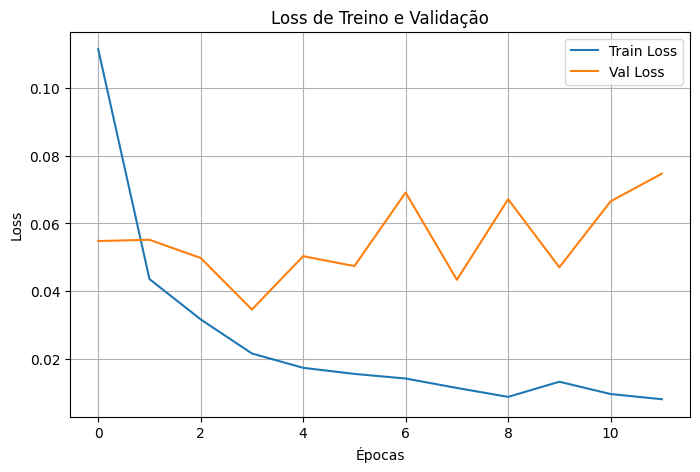

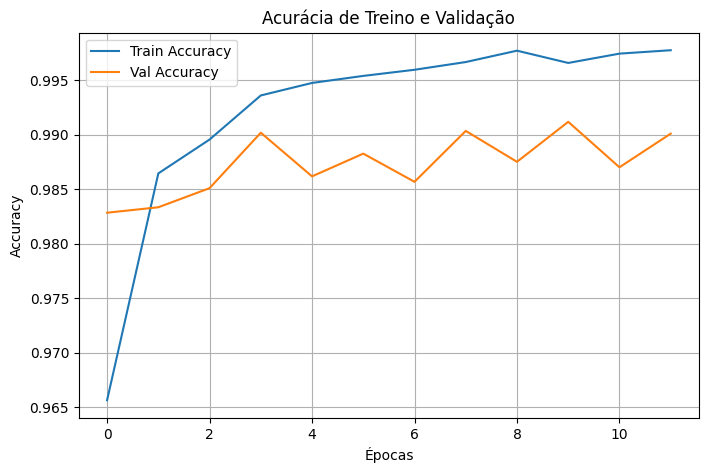

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Loss de Treino e Validação")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Acurácia de Treino e Validação")
plt.legend()
plt.grid(True)
plt.show()

**11) CARREGAR MELHOR MODELO EM UMA NOVA INSTÂNCIA**

In [27]:
best_model = ConvNet().to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

print("Melhor modelo carregado com sucesso.")

Melhor modelo carregado com sucesso.


**12) TESTE FINAL**

In [28]:
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total
print(f"Acurácia final no conjunto de teste: {test_acc * 100:.2f}%")

Acurácia final no conjunto de teste: 99.09%
